In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_dilated_convolutions import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()



train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.5).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

Antal utan m-komponent i träningsdatan: 30391
Antal med m-komponent i träningsdatan: 4852
Epoch   0 | train: 0.0741 | val: 0.0932 | acc: 96.68% | AUC: 0.994  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   1 | train: 0.0658 | val: 0.0876 | acc: 96.77% | AUC: 0.996  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   2 | train: 0.0628 | val: 0.0801 | acc: 98.14% | AUC: 0.996  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   3 | train: 0.0642 | val: 0.0746 | acc: 98.28% | AUC: 0.995  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   4 | train: 0.0579 | val: 0.0698 | acc: 98.14% | AUC: 0.996  | LR: 0.001
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   5 | train: 0.0621 | val: 0.0715 | acc: 98.25% | AUC: 0.996  | LR: 0.001
Epoch   6 | train: 0.0547 | val: 0.0771 | acc: 98.45% |

              precision    recall  f1-score   support

     Negativ       1.00      0.97      0.98      7184
     Positiv       0.71      0.96      0.82       532

    accuracy                           0.97      7716
   macro avg       0.85      0.97      0.90      7716
weighted avg       0.98      0.97      0.97      7716

[[6974  210]
 [  21  511]]
AUC: 0.9920638700035165
Accuracy:  97.01%
FN-rate:   3.95%  (farliga missade fall)
FP-rate:   2.92%  (onödiga larm)
Sensitivitet:   96.05%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   97.08%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9921


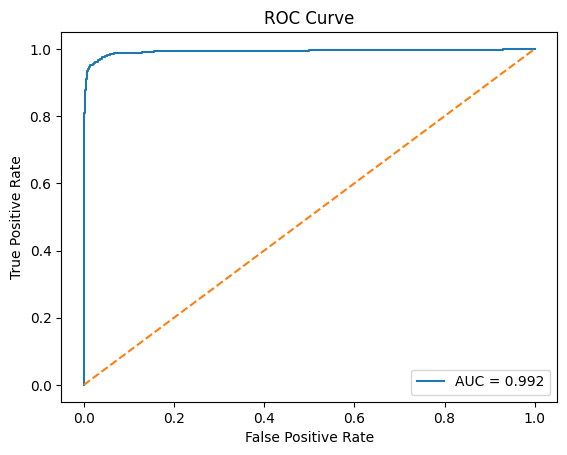

In [3]:
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = CNN.predict(test_rows)
_ = evaluate(result)